# Splitting the PDF

This notebook contains the code and outlines my approach for preparing a scholarly edition of an Ottoman text for text extraction with Gemini

## Requirements

You will need the following libraries:
* [pypdf](https://pypi.org/project/pypdf/): A pure-python PDF library capable of splitting, merging, cropping, and transforming PDF files
* [pdf2image](https://pypi.org/project/pdf2image/): A python (3.7+) module that wraps pdftoppm and pdftocairo to convert PDF to a PIL Image object
  * To use this library on a Mac you need [poppler](https://poppler.freedesktop.org/), which is installed using [Brew](https://brew.sh/)
* Optionally: matplotlib to display images of PDF pages more neatly

In [1]:
import os
from pypdf import PdfReader, PdfWriter

# PDF file path to the full PDF including the introductory materials
pdf_path = '../pdf_corpus/full_PDFs/vasif_1789-1794.pdf'  # These files are not included in the repository

reader = PdfReader(pdf_path)

# To verify it loaded: print number of pages
# I am expecting 561 pages
print(f"PDF loaded successfully. Total pages: {len(reader.pages)}")

PDF loaded successfully. Total pages: 561


The code below helps us see the pages of the PDF. This is super helpful because in the next step we will remove all pages except the main transliteration content. For this, we will determine a page range that we want to keep by looking at where the transliteration begins and ends in the PDF itself. This is a manual process. The issue is that pypdf, which is the Python library that we use for this purpose is 0-indexed, whereas PDF readers in our computers like Preview or Adobe begin numeration of pages with 1. Printing the pages that we want to split by helps us verify that we are on the right track.

You could also do this in Adobe Acrobat Pro by manually selecting the pages that contain the transliteration and extracting them into a new PDF. There are ways to do it online, too. I prefer to do it with code since we will be splitting the transliteration PDF into individual pages and looping over them anyways.

In [ ]:
from pdf2image import convert_from_path
# Convert and display first page as image
# note that pdf2image uses 1-based indexing, not 0-based like pypdf
images = convert_from_path(pdf_path, first_page=1, last_page=1) #this is a list of PIL images, len 1
images[0]

Perfect! Now that we know that this is working, let's set our page range and test it.

In [5]:
# first page of the transliteration on my Adobe Acrobat PDF Reader is 154, since pypdf uses 0-indexing, we subtract 1 
start_page = 153

# last page of the transliteration on my Adobe Acrobat PDF Reader is 540, since pypdf uses 0-indexing, we subtract 1
end_page = 539

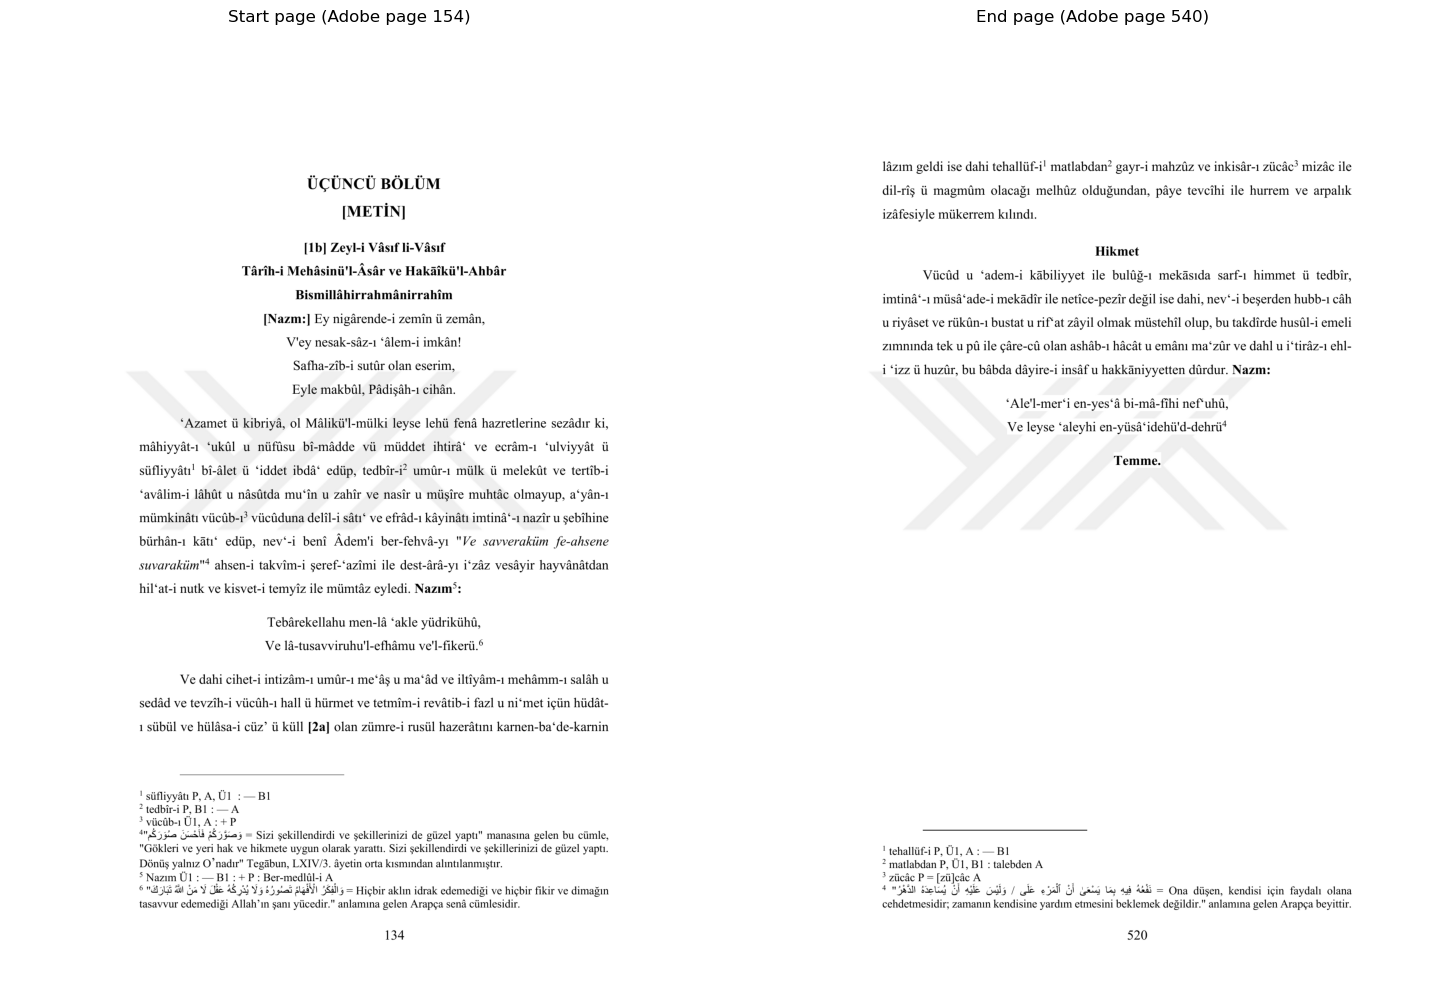

In [ ]:
# Let's verify these pages by converting them to images and displaying them
# we will do it a bit more nicely this time with matplotlib but you don't need to, just follow the code above for checking out the first image

import matplotlib.pyplot as plt

# Convert both pages to images
# Remember pdf2image uses 1-based indexing!
start_images = convert_from_path(pdf_path, first_page=154, last_page=154)
end_images = convert_from_path(pdf_path, first_page=540, last_page=540)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

axes[0].imshow(start_images[0])
axes[0].set_title('Start page (Adobe page 154)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(end_images[0])
axes[1].set_title('End page (Adobe page 540)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Yes, we got the correct page range! Quick note: the page numbers in the text differ from the PDF page numbers (134 and 520). This is because the author enumerated pages starting with unnumbered elements like the title page, or used Roman numerals for sections like the abstract (i, ii, etc.). At this stage, "page number" refers to the PDF page number, not the text's printed page number.

In [6]:
# Let's save this new PDF with only the transliteration content

output_pdf_path = '../pdf_corpus/just_ottoman_PDFs/vasif_1789-1794.pdf' # not accesible in the repository

writer = PdfWriter()
# range is not inclusive of the end, so we add 1
for page_num in range(start_page, end_page + 1):
    writer.add_page(reader.pages[page_num])

with open(output_pdf_path, "wb") as output_pdf_file:
    writer.write(output_pdf_file)

Finally, we will split the new PDF into individual pages and save them in a folder. As noted above, the page numbers in the text differ from the PDF page numbers. When creating individual page PDFs, we will name them according to their in-text page numbers. For example, the first page of the transliteration (PDF page 154) will be named page_134.pdf, as it corresponds to page 134 in the text.

This will make it easier in the next notebook to double check Gemini's text extraction work. We are anyways no longer working with one PDF but 387 single-page PDF files

In [9]:
# Create output folder
output_folder = 'transliteration_pages'
os.makedirs(output_folder, exist_ok=True)

# Calculate the offset between Adobe page numbers and printed page numbers
# Adobe page 154 = printed page 134, so offset is 20
page_offset = 154 - 134  # 20

# Split and save individual pages
for page_num in range(start_page, end_page + 1):
    writer = PdfWriter()
    writer.add_page(reader.pages[page_num])
    
    # Calculate the printed page number (Adobe page number - offset)
    printed_page_num = (page_num + 1) - page_offset

    # Save the page
    output_path = os.path.join(output_folder, f'page_{printed_page_num}.pdf')
    with open(output_path, 'wb') as output_file:
        writer.write(output_file)

In [10]:
# Our new PDF with only the transliteration content has 387 pages, as expected.
# Let's confirm that we have 387 individual page PDFs in the output folder.
split_files = os.listdir(output_folder)
print(f"Total individual page PDFs created: {len(split_files)}")  # Should be 387

Total individual page PDFs created: 387


## What if the scan is double-paged?

Some PDFs in this corpus are scanned from printed books. In this case, we can't feed them into the OCR prompting pipeline because we don't have any double-paged examples in our few-shot collection. Instead, we will use `pypdf` to split them into single paged copies.

![double-paged pdf](double_page_pdf.png)

In [7]:
from pypdf import PdfReader, PdfWriter
from pypdf.generic import RectangleObject
import copy

INPUT_PDF = "/Users/mervetekgurler/Documents/ottoman-court-histories/pdf_corpus/full_PDFs/cabi_1788-1814.pdf"
OUTPUT_PDF = "/Users/mervetekgurler/Documents/ottoman-court-histories/pdf_corpus/full_PDFs/cabi_1788-1814_split.pdf"
PAGES_TO_SPLIT = 10  # first 10 pages

def split_page_in_half(page):
    media_box = page.mediabox
    x0, y0, x1, y1 = map(float, [media_box.left, media_box.bottom, media_box.right, media_box.top])
    mid_x = (x0 + x1) / 2.0

    left_box = RectangleObject([x0, y0, mid_x, y1])
    right_box = RectangleObject([mid_x, y0, x1, y1])

    left_page = copy.copy(page)
    left_page.mediabox = left_box
    left_page.cropbox = left_box

    right_page = copy.copy(page)
    right_page.mediabox = right_box
    right_page.cropbox = right_box

    return left_page, right_page

In [8]:
reader = PdfReader(INPUT_PDF)
writer = PdfWriter()

total_pages = len(reader.pages)
max_pages = min(PAGES_TO_SPLIT, total_pages)

for i in range(max_pages):
    page = reader.pages[i]
    left_page, right_page = split_page_in_half(page)
    writer.add_page(left_page)
    writer.add_page(right_page)

with open(OUTPUT_PDF, "wb") as f:
    writer.write(f)

print(f"Saved split PDF to: {OUTPUT_PDF}")


Saved split PDF to: /Users/mervetekgurler/Documents/ottoman-court-histories/pdf_corpus/full_PDFs/cabi_1788-1814_split.pdf
